<h3><b>Introduction</b></h3>
<p> The goal of this project is to take the AQMRG relay data and apply machine learning techniques to see if we can predict the amount of PM2.5 concentration in the air given other environmental features. This notebook is adapted from a similar project for Beijing air quality monitoring.</p>
<br>
<h5><b>Project workflow</b></h5>
<ul>
    <li>Import the necessary libraries and loading the data</li>
    <li>Data preprocessing</li>
    <li>Exploratory Data Analysis</li>
    <li>Model training and Evaluation</li>
</ul>
<br>
<h5><b>Import libraries and loading data</b></h5>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings(action='ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from IPython.display import display

In [3]:
file = 'aqmrg_relay_data_20260309_211207.csv'
data = pd.read_csv(file)
data.head()

,ID,Timestamp (EAT),Device ID,PM1,PM2.5,PM10,CO,CO2,Temperature,Humidity,VOC Index,NOx Index,Latitude,Longitude
0,1470,2026-03-10 00:12:01,868428040514113,99.0,201.0,225.0,1.94,-1.0,33.1,45.6,100.0,1.0,-1.2833,36.8167
1,1469,2026-03-10 00:07:00,868428040514113,100.0,202.0,233.0,1.94,-1.0,33.2,45.6,100.0,1.0,-1.2833,36.8167
2,1468,2026-03-10 00:02:00,868428040514113,100.0,206.0,243.0,0.00,-1.0,33.0,45.7,100.0,1.0,-1.2833,36.8167
3,1467,2026-03-09 23:57:00,868428040514113,101.0,212.0,251.0,3.87,-1.0,33.2,45.6,100.0,1.0,-1.2833,36.8167
4,1466,2026-03-09 23:52:00,868428040514113,116.0,223.0,257.0,0.00,-1.0,33.2,45.6,100.0,1.0,-1.2833,36.8167


<h3><b>Data Preprocessing</b></h3>

In [4]:
# Drop irrelevant columns
cols_to_drop = ['ID', 'Device ID', 'Latitude', 'Longitude']
data = data.drop(cols_to_drop, axis=1)

# Convert timestamp to datetime and extract features
data['Timestamp (EAT)'] = pd.to_datetime(data['Timestamp (EAT)'])
data['year'] = data['Timestamp (EAT)'].dt.year
data['month'] = data['Timestamp (EAT)'].dt.month
data['day'] = data['Timestamp (EAT)'].dt.day
data['hour'] = data['Timestamp (EAT)'].dt.hour

# Check for null values
print('Null values in each column:')
display(data.isnull().sum())

# Fill missing values with mean
data.fillna(data.mean(numeric_only=True), inplace=True)

data.info()

Null values in each column:


Timestamp (EAT)    0
PM1                4
PM2.5              0
PM10               3
CO                 4
CO2                2
Temperature        2
Humidity           2
VOC Index          4
NOx Index          4
year               0
month              0
day                0
hour               0
dtype: int64

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Timestamp (EAT)  1470 non-null   datetime64[us]
 1   PM1              1470 non-null   float64       
 2   PM2.5            1470 non-null   float64       
 3   PM10             1470 non-null   float64       
 4   CO               1470 non-null   float64       
 5   CO2              1470 non-null   float64       
 6   Temperature      1470 non-null   float64       
 7   Humidity         1470 non-null   float64       
 8   VOC Index        1470 non-null   float64       
 9   NOx Index        1470 non-null   float64       
 10  year             1470 non-null   int32         
 11  month            1470 non-null   int32         
 12  day              1470 non-null   int32         
 13  hour             1470 non-null   int32         
dtypes: datetime64[us](1), float64(9), int32(4)
memory u

<h3><b>Exploratory Data Analysis</b></h3>

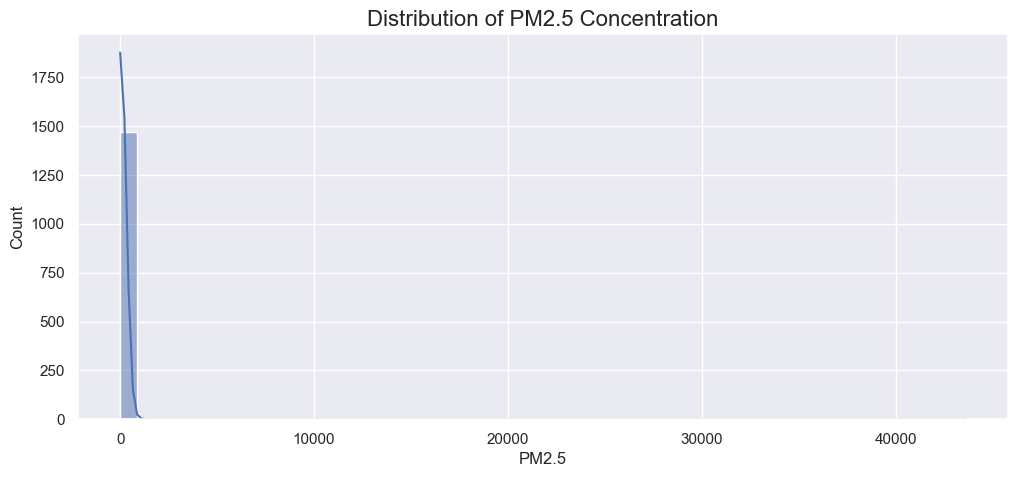

In [5]:
plt.figure(figsize=(12,5))
sns.histplot(data['PM2.5'], bins=50, kde=True)
plt.title('Distribution of PM2.5 Concentration', fontsize=16)
plt.show()

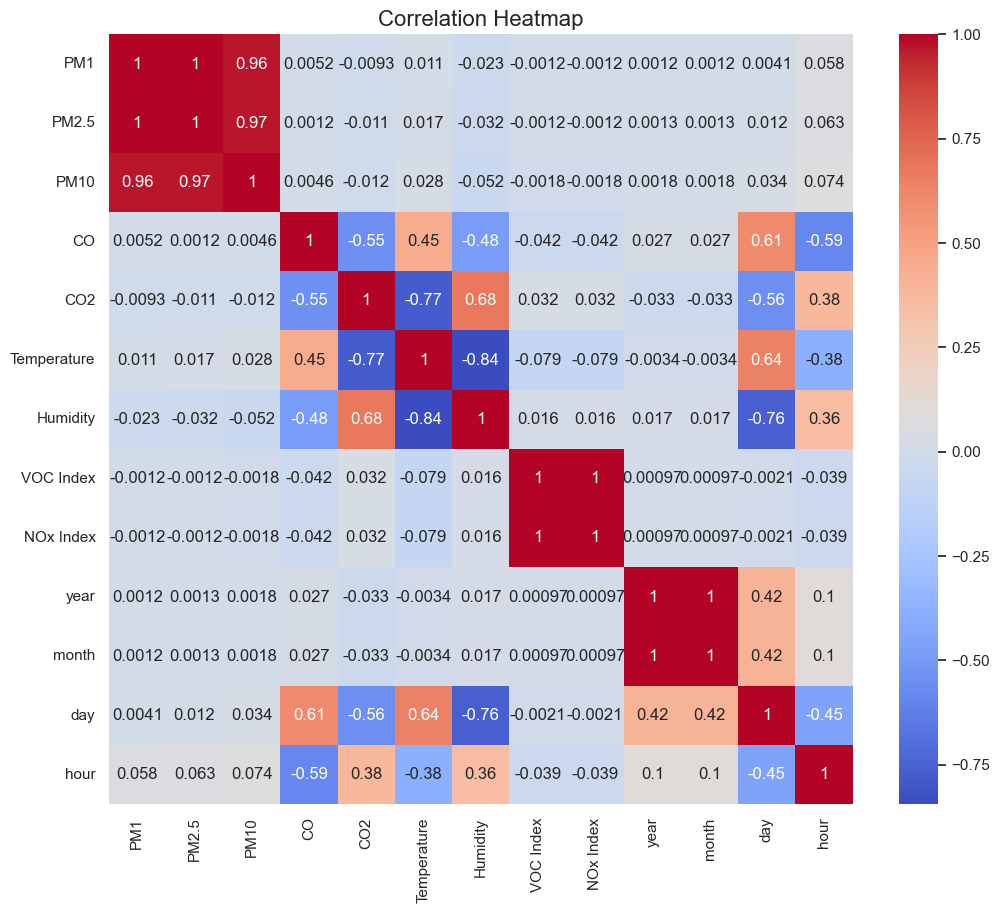

In [6]:
plt.figure(figsize=(12,10))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

<h3><b>Model Training and Evaluation</b></h3>

In [7]:
# Prepare features and target
X = data.drop(['PM2.5', 'Timestamp (EAT)'], axis=1)
y = data['PM2.5']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def evaluate_model(model, name):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    r2 = r2_score(y_test, pred)
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    print(f'--- {name} ---')
    print(f'R2 Score: {r2:.4f}')
    print(f'RMSE: {rmse:.4f}\n')

evaluate_model(LinearRegression(), 'Linear Regression')
evaluate_model(RandomForestRegressor(n_estimators=100), 'Random Forest')
evaluate_model(GradientBoostingRegressor(), 'Gradient Boosting')

--- Linear Regression ---
R2 Score: 0.6820
RMSE: 42.3847

--- Random Forest ---
R2 Score: 0.9562
RMSE: 15.7334

--- Gradient Boosting ---
R2 Score: 0.9715
RMSE: 12.6798

